# 02 — Feature distributions

**Owner:** Juan (D2)

Visual sanity check on `feature_table.parquet` before M1/M2 train on it. One figure per BG/NBD input + class balance + correlation heatmap.

Source pipeline: `data/features/customer_features.csv` (canonical, upstream) → `src/features/build.py` → `data/features/feature_table.parquet`. This notebook never re-derives features.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.features.build import class_balance

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

FEATURES_PATH = "../data/features/feature_table.parquet"
CHURN_WINDOW_DAYS = 299

In [2]:
features = pd.read_parquet(FEATURES_PATH)
print(f"Shape: {features.shape}")
print(f"Columns: {features.columns.tolist()}")
features.head()

Shape: (751956, 17)
Columns: ['customer_id', 'frequency', 'recency', 't', 'days_since_last_order', 'monetary_value', 'avg_order_value', 'total_orders', 'total_revenue', 'avg_days_between_orders', 'std_days_between_orders', 'refund_count', 'total_refund_amount', 'refund_rate', 'first_order_date', 'last_order_date', 'is_churned']


,customer_id,frequency,recency,t,days_since_last_order,monetary_value,avg_order_value,total_orders,total_revenue,avg_days_between_orders,std_days_between_orders,refund_count,total_refund_amount,refund_rate,first_order_date,last_order_date,is_churned
0,43d49e501840d6909e34db122d651acb,420,804,804,0,116.82,116.82,421,49181.28,1.0,0.1,0,0.0,0.0,2024-01-01 17:01:23,2026-03-15 01:17:31,0
1,d29cb3376e670e5201dbb7a17f1073cd,80,762,803,41,270.56,270.56,81,21915.43,19.5,28.1,0,0.0,0.0,2024-01-02 22:27:01,2026-02-02 11:19:46,0
2,612feec0473dcb46b40e499d63f31584,187,749,803,54,88.28,88.28,188,16595.83,5.3,5.2,0,0.0,0.0,2024-01-02 18:30:00,2026-01-20 09:11:46,0
3,3af1f5a4d635314aaf0ed5fa51b8280a,3,200,640,440,1787.97,1787.97,4,7151.86,66.7,45.3,0,0.0,0.0,2024-06-13 03:05:46,2024-12-30 13:39:24,1
4,e13501520f1754ef39a8575d454fd33c,3,16,788,772,1590.78,1590.78,4,6363.11,8.0,1.4,0,0.0,0.0,2024-01-17 03:30:21,2024-02-02 06:19:52,1


## Class balance

{'n': 751956, 'n_churned': 367372, 'n_active': 384584, 'pct_churned': 0.4885551814201895, 'extreme': False}


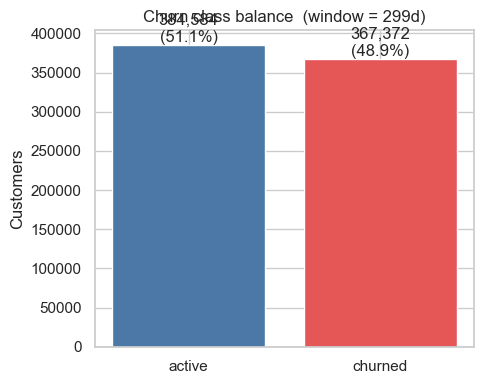

In [3]:
bal = class_balance(features)
print(bal)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["active", "churned"], [bal["n_active"], bal["n_churned"]], color=["#4C78A8", "#E45756"])
for i, v in enumerate([bal["n_active"], bal["n_churned"]]):
    ax.text(i, v, f"{v:,}\n({v/bal['n']:.1%})", ha="center", va="bottom")
ax.set_ylabel("Customers")
ax.set_title(f"Churn class balance  (window = {CHURN_WINDOW_DAYS}d)")
plt.tight_layout()
plt.savefig("../docs/figures/features_class_balance.png", dpi=120)
plt.show()

## BG/NBD + Gamma-Gamma input distributions

One figure per modeling input.

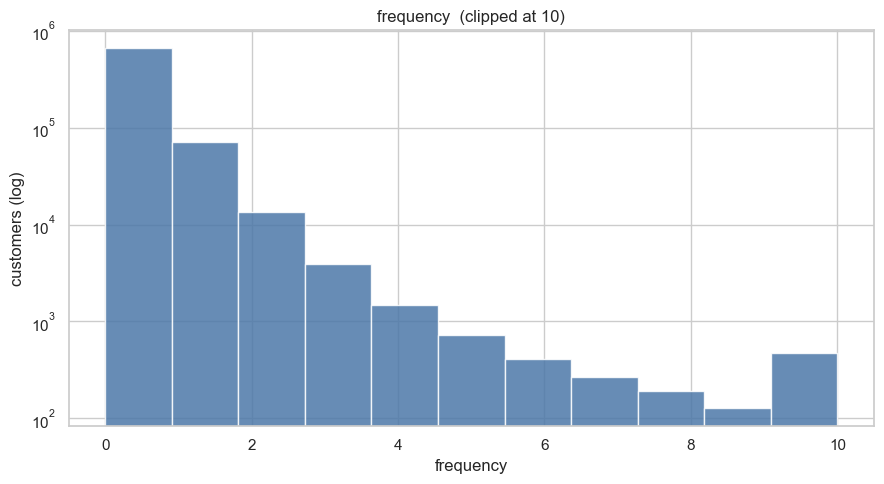

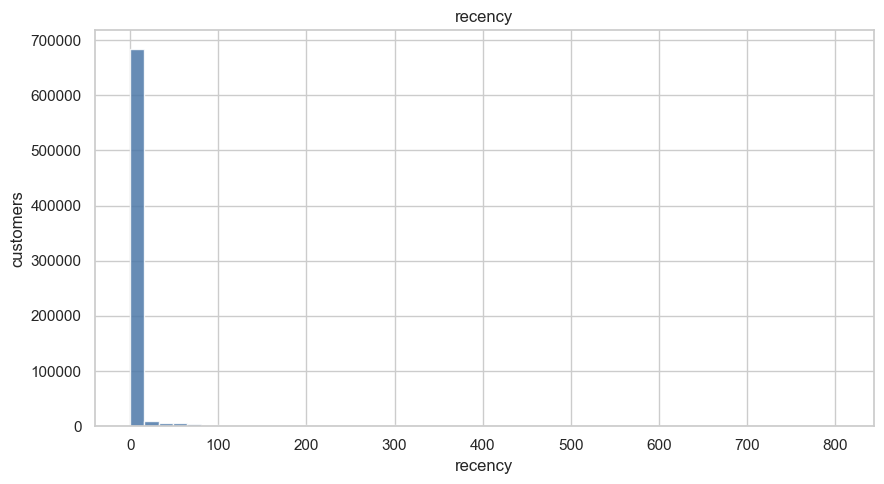

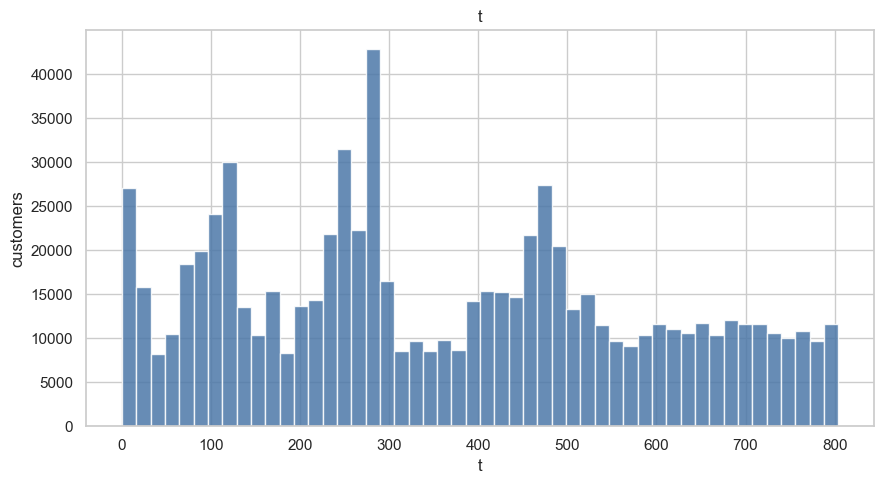

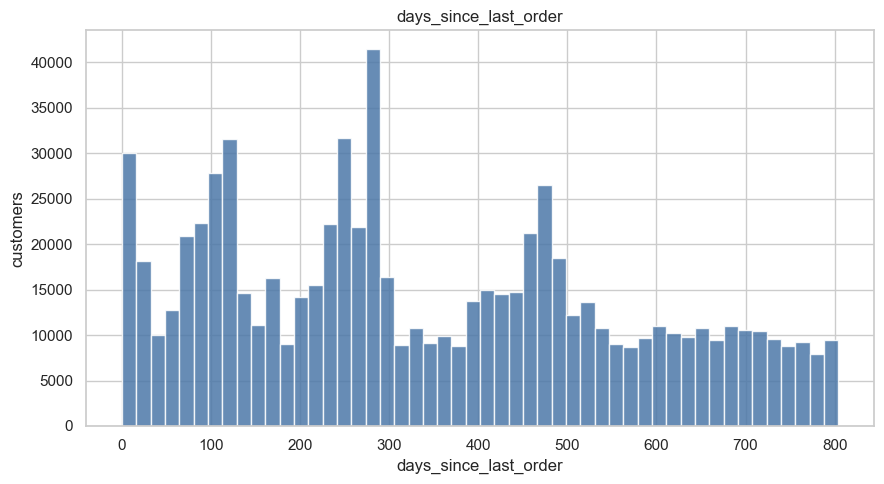

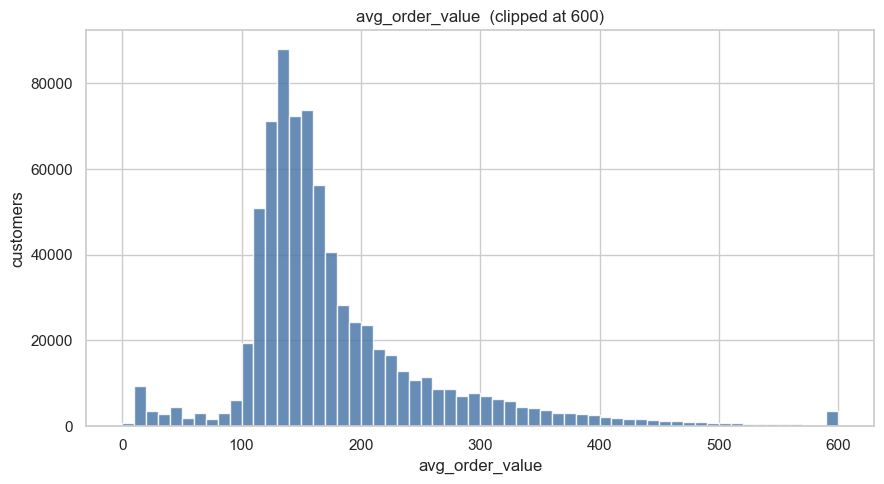

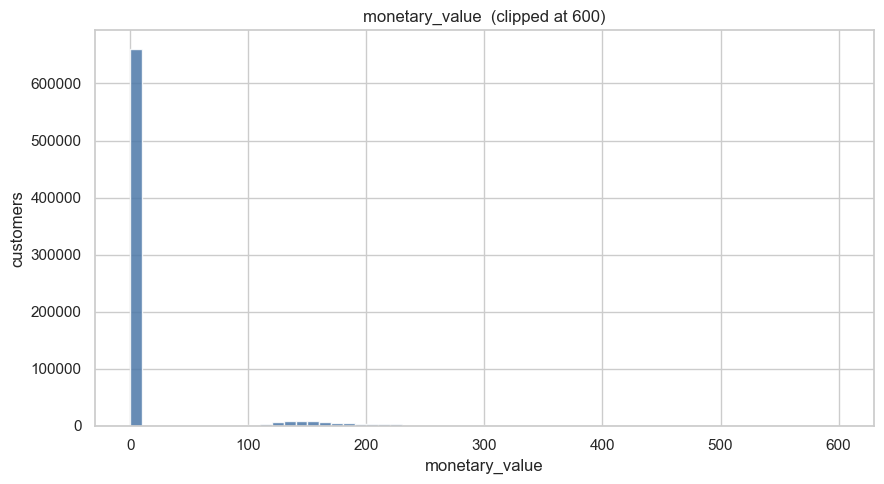

In [4]:
def hist(col, clip=None, bins=50, log=False):
    s = features[col].clip(upper=clip) if clip else features[col]
    fig, ax = plt.subplots()
    ax.hist(s, bins=bins, color="#4C78A8", alpha=0.85)
    if log:
        ax.set_yscale("log")
    title = col
    if clip:
        title += f"  (clipped at {clip})"
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("customers (log)" if log else "customers")
    plt.tight_layout()
    plt.savefig(f"../docs/figures/features_{col}.png", dpi=120)
    plt.show()

hist("frequency", clip=10, bins=11, log=True)
hist("recency", bins=50)              # BG/NBD recency = last - first
hist("t", bins=50)                     # BG/NBD T = snapshot - first
hist("days_since_last_order", bins=50) # snapshot recency (drives churn label)
hist("avg_order_value", clip=600, bins=60)
hist("monetary_value", clip=600, bins=60)  # Gamma-Gamma input

## Recency vs tenure (BG/NBD invariant check)

Every point should lie on or below the diagonal — `recency <= t`.

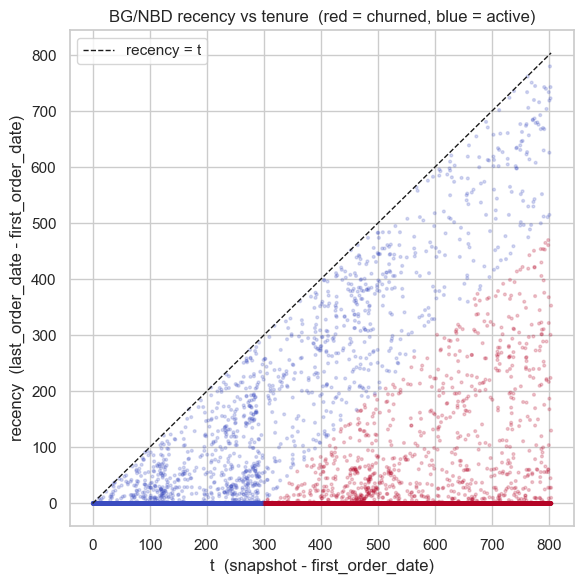

In [5]:
sample = features.sample(min(20000, len(features)), random_state=0)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample["t"], sample["recency"], s=4, alpha=0.2, c=sample["is_churned"], cmap="coolwarm")
lim = max(features["t"].max(), features["recency"].max())
ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="recency = t")
ax.set_xlabel("t  (snapshot - first_order_date)")
ax.set_ylabel("recency  (last_order_date - first_order_date)")
ax.set_title("BG/NBD recency vs tenure  (red = churned, blue = active)")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/figures/features_recency_vs_t.png", dpi=120)
plt.show()

## Feature correlations  (multicollinearity hint for M2)

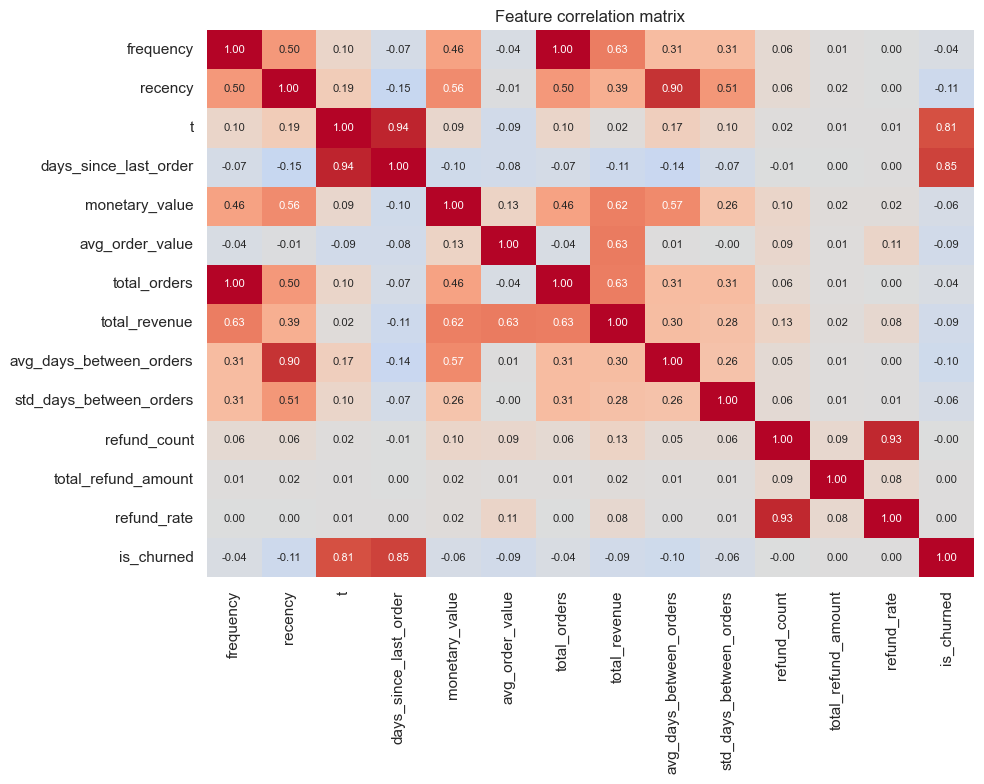

In [6]:
drop = ["customer_id", "first_order_date", "last_order_date"]
corr = features.drop(columns=drop).corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar=False, annot_kws={"size": 8})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("../docs/figures/features_correlations.png", dpi=120)
plt.show()

## Step 3 acceptance criteria
- [x] `feature_table.parquet` exists  (saved by `build_features` runner)
- [x] All validation asserts pass  (inside `build_features`)
- [x] `SCHEMA.md` documents each column
- [x] Notebook 02 demonstrates feature distributions
- [ ] Path + class balance posted in #team channel  → done in Step 5